# Overview entanglement generated by quantum nondemolition measurements

In [1]:
from dataclasses import replace

In [2]:
import numpy as np
from matplotlib.pyplot import subplots
from qutip import sesolve, fidelity, entropy_vn, ptrace
from tqdm import tqdm
from joblib import Parallel, delayed

In [3]:
import sys
from pathlib import Path

sys.path.extend([str(p) for p in (Path.cwd().parent / "dependencies").iterdir()])

In [4]:
%reload_ext autoreload
%autoreload 2

import bec

## Model

In [5]:
n_bosons = 4  # N
model = bec.BEC_Qubits.init_default(n_bosons, 0)
model = replace(
    model,
    communication_line=True,
    communication_line_levels=3,
)
model

BEC_Qubits(n_bosons=4, coupling_strength=1, transition_ampl=1, transition_freq=11, resonance_freq=1, phase=0, excitation_level=False, communication_line=True, communication_line_levels=3)

## Initial state

$$|\Psi_0\rangle = \frac{(e^\dagger + g^\dagger)^N}{\sqrt(2N!)} e^{-|\alpha|^2 / 2}e^{\alpha\frac{c^\dagger_1 + c^\dagger_2}{\sqrt{2}}}|\mathrm{vac}\rangle$$

In [6]:
alpha = 1

In [7]:
init_state = (
    bec.coherent_state_constructor(model, n=2, k=0)
    * bec.coherent_state_constructor(model, n=2, k=1)
    * np.exp(-np.abs(alpha) ** 2 / 2)
    * (
        alpha
        * (bec.c(model, n=2, k=0).dag() + bec.c(model, n=2, k=1).dag())
        / np.sqrt(2)
    ).expm()
    * bec.vacuum_state(model, n=2)
)
init_state.dag()

Quantum object: dims=[[1, 1, 1, 1, 1, 1], [5, 5, 3, 5, 5, 3]], shape=(1, 5625), type='bra', dtype=Dense
Qobj data =
[[0. 0. 0. ... 0. 0. 0.]]

In [8]:
init_state.norm()

0.9856123220330292

*Why initial state norm is not equal to one?*

In [9]:
init_state = init_state / init_state.norm()

## Hamiltonian

The Stokes operator in the z-direction for the optical modes is

$$ J_z = c_1^\dagger c_1 - c_2^\dagger c_2 $$

In [10]:
stokes_oper = bec.c(model, n=2, k=0).dag() * bec.c(model, n=2, k=0) - bec.c(
    model, n=2, k=1
).dag() * bec.c(model, n=2, k=1)

$$ \cal{H} = (S_1^z + S_2^z)J_z$$

In [11]:
ham = (bec.sz(model, n=2, k=0) - bec.sz(model, n=2, k=1)) * stokes_oper

## Evolution

$$|\Psi(t)\rangle = e^{-i\cal{H}t}|\Psi_0\rangle$$

In [12]:
t_list, dt = np.linspace(0, np.pi, 101, retstep=True)

In [13]:
states = sesolve(ham, init_state, t_list).states

Text(0.5, 0, 't, Evolution time')

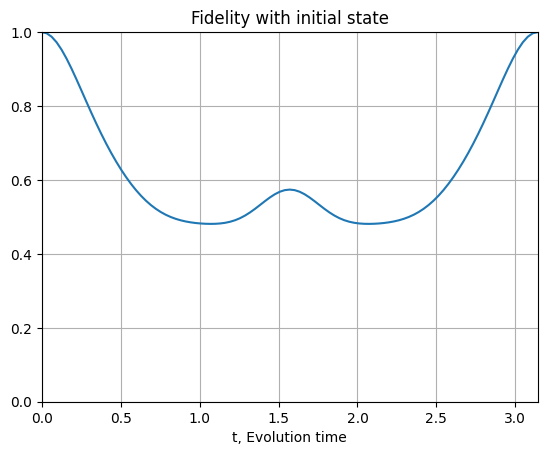

In [14]:
_, ax = subplots(1, 1)
ax.set_title("Fidelity with initial state")
ax.plot(t_list, [fidelity(s, init_state) for s in states])
ax.grid(True)
ax.set_ylim(0, 1)
ax.set_xlim(t_list[0], t_list[-1])
ax.set_xlabel("t, Evolution time")

## Projecting the light on Fock states

After interacting with the two BECs, a 50:50 beam splitter transforms the photon modes according to

$$ c_1 = \frac{1}{\sqrt 2} (d_1 + d_2), \quad c_2 = \frac{1}{\sqrt 2} (d_1 - d_2) $$

After the measurement the state of the photons in mode $d_1$ is

$$ 
    |n_{d_1}n_{d_2}\rangle 
    = \frac{\left(d_1^\dagger\right)^{n_{d_1}}}{\sqrt{n_{d_1}!}} 
      \frac{\left(d_2^\dagger\right)^{n_{d_2}}}{\sqrt{n_{d_2}!}} 
      | \mathrm{vac} \rangle 
$$

where

$$ d_1 = \frac{1}{\sqrt 2} (c_1 + c_2), \quad d_2 = \frac{1}{\sqrt 2} (c_1 - c_2) $$

In [15]:
def photon_counter_constructor(n1, n2):
    return (
        ((bec.c(model, n=2, k=0).dag() + bec.c(model, n=2, k=1).dag()) / np.sqrt(2))
        ** n1
        / np.sqrt(np.prod(range(1, n1 + 1)))
        * ((bec.c(model, n=2, k=0).dag() - bec.c(model, n=2, k=1).dag()) / np.sqrt(2))
        ** n2
        / np.sqrt(np.prod(range(1, n2 + 1)))
    )

$$ |n_{d_1}n_{d_2}\rangle\langle n_{d_1}n_{d_2}| \Psi(t)\rangle $$

In [16]:
n1, n2 = 2, 0
photon_counter_oper_constructor_n1_n2 = (
    photon_counter_constructor(n1, n2) * photon_counter_constructor(n1, n2).dag()
)


def measure_photons(s):
    s_ = photon_counter_oper_constructor_n1_n2 * s
    return s_ / s_.norm()

In [17]:
measured_photon_states = Parallel(n_jobs=-2)(
    delayed(measure_photons)(s) for s in tqdm(states)
)

100%|██████████| 101/101 [00:01<00:00, 69.56it/s]


In [18]:
entropies = Parallel(n_jobs=-2)(
    delayed(lambda x: entropy_vn(ptrace(x, [0, 1])) / np.log2(n_bosons + 1))(s)
    for s in tqdm(measured_photon_states)
)

100%|██████████| 101/101 [00:10<00:00, 10.05it/s]


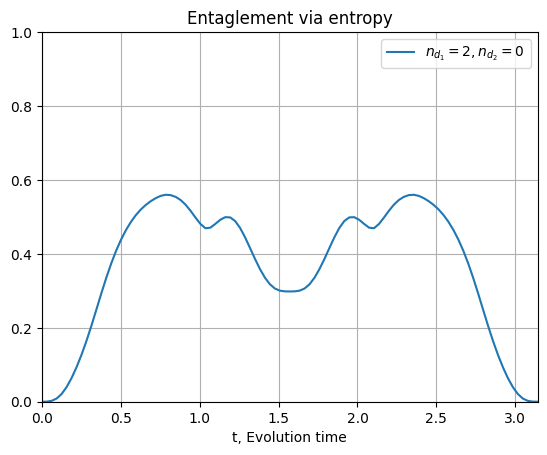

In [19]:
_, ax = subplots(1, 1)
ax.set_title("Entaglement via entropy")
ax.plot(t_list, entropies, label=rf"$n_{{d_1}}={n1}, n_{{d_2}}={n2}$")
ax.set_ylim(0, 1)
ax.set_xlim(t_list[0], t_list[-1])
ax.set_xlabel("t, Evolution time")
ax.grid(True)
ax.legend()